In [184]:
import sys
from pathlib import Path

project_root = Path().resolve()
while not (project_root / "src").exists():
    project_root = project_root.parent

sys.path.append(str(project_root))

In [203]:
import pandas as pd
from src.utils.utils import load_config
from src.data.data import load_txt
import seaborn as sns
import matplotlib.pyplot as plt
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [186]:
config = load_config("configs/config.yaml")

df = load_txt(config['data']['raw_path'], names=['text', 'label'])

## General Datachecks

In [187]:
df.shape

(2264, 2)

In [188]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    2264 non-null   str  
 1   label   2264 non-null   str  
dtypes: str(2)
memory usage: 35.5 KB


In [189]:
pd.set_option('display.max_colwidth', None)
df.head()

,text,label
0,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",neutral
1,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .",positive
2,"In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .",positive
3,Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales .,positive
4,"Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales .",positive


In [190]:
df['label'].value_counts()

label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

In [191]:
df.isna().sum()

text     0
label    0
dtype: int64

In [192]:
df.duplicated().sum()

np.int64(5)

In [193]:
df[df.duplicated(subset=["text"], keep=False)]


,text,label
518,The issuer is solely responsible for the content of this announcement .,neutral
519,The issuer is solely responsible for the content of this announcement .,neutral
625,"The report profiles 614 companies including many key and niche players worldwide such as Black & Decker Corporation , Fiskars Corporation , Fiskars Brands , Inc. , Husqvarna Outdoor Products Inc. , K+S Group , Ryobi Technologies , Inc. , The Scotts Miracle-Gro Company , and Van Group , Inc. .",neutral
626,"The report profiles 614 companies including many key and niche players worldwide such as Black & Decker Corporation , Fiskars Corporation , Fiskars Brands , Inc. , Husqvarna Outdoor Products Inc. , K+S Group , Ryobi Technologies , Inc. , The Scotts Miracle-Gro Company , and Van Group , Inc. .",neutral
928,Ahlstrom 's share is quoted on the NASDAQ OMX Helsinki .,neutral
929,Ahlstrom 's share is quoted on the NASDAQ OMX Helsinki .,neutral
1026,"SSH Communications Security Corporation is headquartered in Helsinki , Finland .",neutral
1027,"SSH Communications Security Corporation is headquartered in Helsinki , Finland .",neutral
1408,"The company serves customers in various industries , including process and resources , industrial machinery , architecture , building , construction , electrical , transportation , electronics , chemical , petrochemical , energy , and information technology , as well as catering and households .",neutral
1409,"The company serves customers in various industries , including process and resources , industrial machinery , architecture , building , construction , electrical , transportation , electronics , chemical , petrochemical , energy , and information technology , as well as catering and households .",neutral


In [194]:
conflicts = pd.DataFrame(df[df.duplicated()].groupby("text")["label"].nunique())

conflicts

,label
text,
Ahlstrom 's share is quoted on the NASDAQ OMX Helsinki .,1
"SSH Communications Security Corporation is headquartered in Helsinki , Finland .",1
"The company serves customers in various industries , including process and resources , industrial machinery , architecture , building , construction , electrical , transportation , electronics , chemical , petrochemical , energy , and information technology , as well as catering and households .",1
The issuer is solely responsible for the content of this announcement .,1
"The report profiles 614 companies including many key and niche players worldwide such as Black & Decker Corporation , Fiskars Corporation , Fiskars Brands , Inc. , Husqvarna Outdoor Products Inc. , K+S Group , Ryobi Technologies , Inc. , The Scotts Miracle-Gro Company , and Van Group , Inc. .",1


## Sentiment Distribution

In [195]:
df['label'].value_counts()

label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

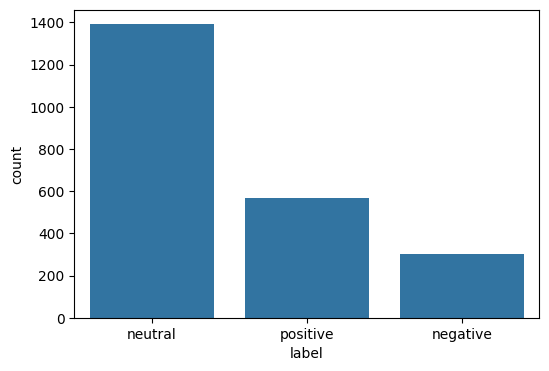

In [196]:
plt.figure(figsize=(6,4))
sns.countplot(df, x='label')
plt.show()

## Text Analysis

In [197]:
df['text_length_no_ws'] = df['text'].str.replace(" ", "").str.len()
df['text_length'] = df['text'].str.len()
df['word_count'] = df["text"].str.replace(f"[{string.punctuation}]", "", regex=True).str.split().str.len()

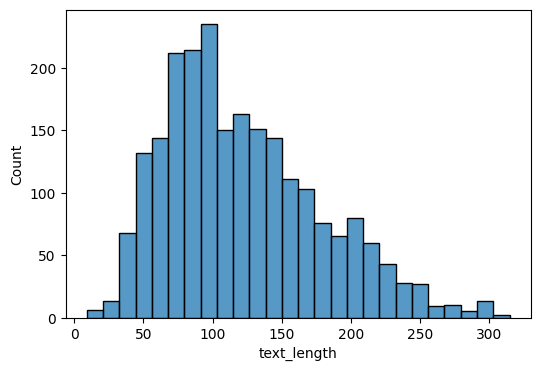

In [198]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='text_length')
plt.show()

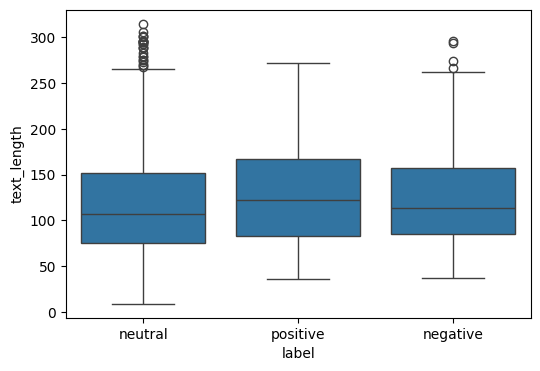

In [199]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, y='text_length', x='label')
plt.show()

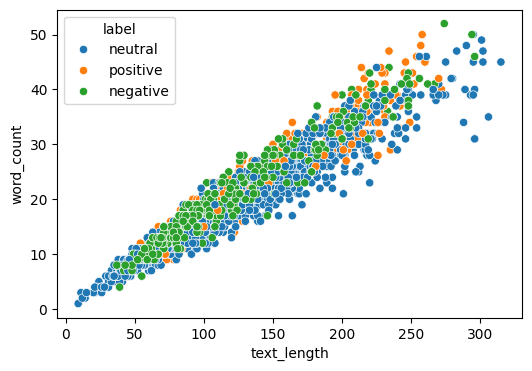

In [200]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='text_length', y='word_count', hue='label')
plt.show()

In [201]:
abc = pd.Series(' '.join(df['text']).lower().split()).value_counts()[:100]
abc

the          2730
.            2219
,            2140
of           1525
in           1384
             ... 
order          57
other          54
decreased      53
not            53
board          51
Name: count, Length: 100, dtype: int64

In [202]:
nltk.download('stopwords')
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/melanie/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
